# Convolutional Neural Network Architecture

This section details the Convolutional Neural Network (CNN) architecture designed for magnetic field prediction. CNNs are specifically suited for processing structured grid data by exploiting spatial relationships through local connectivity and parameter sharing.

## CNN Fundamentals

Convolutional Neural Networks are similar to ordinary neural networks in that they are made up of learnable weights and biases {cite}`lecun1998gradient,krizhevsky2012imagenet`. However, CNNs make an explicit assumption that **input data follows a structured pattern** to store information (usually in the form of a uniform grid such as images, time-series events, or magnetic field distributions).

This assumption introduces certain properties in the architecture which help in:
1. **Reducing the number of parameters** in the network
2. **Making the training process easier** and more efficient
3. **Exploiting spatial relationships** in the data

## Main Layer Types in CNN Architecture

There are three main types of layers present in CNN architecture:

### 1. Convolutional Layer (CONV)

The convolutional layer computes the connection of each neuron with a local region of the input volume. It consists of a set of learnable filters (also called kernels).

```{figure} ../_static/figures/FIG2A.pdf
---
name: fig-conv-kernel
width: 60%
---
Convolution kernel visualization. Blue represents the input map, cyan represents the output map. The filter slides across the input, computing dot products.
```

**Key Properties**:
- Each filter is small spatially compared to the input
- Slides across the entire length and width of the input
- Computes dot products between filter entries and input at each position
- Creates a 2-D activation map (feature map) showing filter response at each position
- Multiple filters learn different features, and their outputs are stacked to form the output volume

**Mathematical Operation**:

For a 2D convolution:
$$
Y[i,j] = \sum_{m} \sum_{n} X[i+m, j+n] \cdot K[m,n] + b
$$

where:
- $X$ is the input
- $K$ is the kernel (filter)
- $Y$ is the output feature map
- $b$ is the bias term

### 2. Pooling Layer (POOL)

The pooling layer is responsible for downsampling the spatial dimensions of the input. Pooling layers are periodically inserted in-between convolutional layers.

**Purpose**:
- Reduce the number of parameters in the network
- Help avoid overfitting
- Provide translation invariance
- Reduce computational cost

**Most Popular Form**: Max pooling with $2 \times 2$ filters applied with stride of 2:
- Down-samples every depth slice by 2 along both width and height
- Reduces spatial dimensions by 75%
- Preserves depth dimension

**Hyperparameters**:
1. **Filter Size**: Typically $2 \times 2$ or $3 \times 3$
2. **Stride**: Step size for sliding the filter (typically 2)

**Example**: A $4 \times 4$ input with $2 \times 2$ max pooling (stride 2) produces a $2 \times 2$ output.

### 3. Fully Connected Layer (FC)

Neurons in fully connected layers have dense connections with all activations in the previous layer, similar to regular neural networks.

**Differences from CONV Layers**:
- **Structure**: CONV layers exhibit local connectivity and parameter sharing
- **Function**: Both compute dot products between weights and activations, followed by non-linear activation

**Purpose**: 
- Balance the locality-context tradeoff
- Relate all features learned by CONV layers
- Develop patterns that capture global trends

**Note**: In modern encoder-decoder architectures for dense prediction (like field estimation), FC layers are often omitted in favor of fully convolutional architectures.

## Dilated Convolutions

A key innovation in the magnetic field prediction architecture is the use of **dilated convolutions** (also called atrous convolutions).

### Standard vs. Dilated Convolution

**Standard Convolution**: Dense kernel captures local relationships

```{figure} ../_static/figures/FIG2A.pdf
---
name: fig-standard-conv
width: 45%
---
Non-dilated convolutional filter with padding. All kernel elements are contiguous.
```

**Dilated Convolution**: Sparse kernel captures distant relationships

```{figure} ../_static/figures/FIG2B.pdf
---
name: fig-dilated-conv
width: 45%
---
Dilated filter with dilation rate of 1. Kernel elements are spaced apart, expanding the receptive field without increasing parameters.
```

### Motivation for Magnetic Field Prediction

**Physical Insight**: The magnetic field at a point can be affected by regions far away from it (the source of excitation). Dilated filters enable spatially distant relations to be captured without:
- Increasing kernel size (more parameters)
- Reducing spatial resolution (pooling)

This is critical for maintaining the **locality-context trade-off** in the network while modeling long-range electromagnetic interactions.

## Encoder-Decoder Architecture

The deep learning model for magnetic field prediction uses an **encoder-decoder architecture**, similar to architectures designed for image segmentation but focused on dense regression instead of classification.

```{figure} ../_static/figures/Network_arch.png
---
name: fig-network-arch
width: 95%
---
Encoder-Decoder based Convolutional Neural Network Architecture for magnetic field prediction.
```

### Encoder Section

The encoder tries to extract spatially related features from the input:

1. **Feature Extraction**: Learns hierarchical representations
2. **Bottleneck Creation**: Compresses information into a latent representation
3. **Spatial Downsampling**: Progressively reduces spatial dimensions via pooling

The encoder creates what is known as a **latent representation** – the most useful information compressed from the high-dimensional input.

### Decoder Section

The decoder uses the latent representation to reconstruct the output:

1. **Semantic Projection**: Projects discriminative features back to input space
2. **Spatial Upsampling**: Progressively increases spatial dimensions
3. **Field Prediction**: Generates the predicted magnetic field distribution

### Skip Connections

The architecture includes skip connections (shown in the diagram) that:
- Connect encoder layers directly to corresponding decoder layers
- Help preserve fine-grained spatial information
- Enable better gradient flow during training
- Similar to U-Net architecture used in medical image segmentation

## Network Specifications

The complete deep learning model consists of:

| Component | Count |
|-----------|-------|
| **Total Layers** | 32 |
| **Trainable Convolutional Layers** | 16 |
| **Pooling/Up-sampling Layers** | 8 |
| **Dropout Layers** | 8 |
| **Total Parameters** | 2.4 Million |

### Layer Configuration

Each encoder/decoder block consists of:
1. Two sets of $3 \times 3$ convolution layers
2. ReLU activation after each convolution
3. Batch normalization layer {cite}`ioffe2015batch`
4. $2 \times 2$ max-pooling (encoder) or up-sampling (decoder) with stride 2
5. Dropout for regularization {cite}`srivastava2014dropout` (typically 0.5 dropout rate)

**Exception**: The last two convolutional layers do not follow this pattern due to a network design constraint to fit the field distribution dimensionality.

### Convolution Details

- **Kernel Size**: $3 \times 3$ (with some $5 \times 5$)
- **Stride**: 1 for all convolutional layers
- **Number of Filters (K)**: Varies by layer, typically K=32 or K=64
- **Dilation**: Alternate dilated layers in encoder with dilation rate of 1

## Training Objective

The network is trained using backpropagation with the aim to **minimize the RMS error** between the prediction and FEA field distribution.

### Loss Function

For magnetic field prediction, the loss function is:

$$
L = \frac{1}{N} \sum_{i=1}^{N} \sqrt{\frac{1}{M} \sum_{j=1}^{M} (B_{ij}^{\text{FEA}} - B_{ij}^{\text{pred}})^2}
$$

where:
- $N$ is the number of samples in a batch
- $M$ is the number of pixels/nodes in each field distribution
- $B_{ij}^{\text{FEA}}$ is the ground truth field from FEA simulation
- $B_{ij}^{\text{pred}}$ is the predicted field from the CNN

### Dataset Partitioning

The dataset is partitioned as follows:

| Partition | Size | Purpose |
|-----------|------|----------|
| **Training** | 30,000 | Parameter optimization |
| **Validation** | 10,000 | Hyperparameter tuning and early stopping |
| **Test** | 5,000 | Final performance evaluation |
| **Total** | 45,000 | Complete dataset |

The geometrical and excitation parameters are populated using **Latin Hypercube Sampling** to ensure comprehensive coverage of the design space.

## Model Capacity and Generalization

For the network to train successfully, it must have **sufficient capacity** to satisfactorily capture the complexity of the electromagnetic field prediction problem. This capability is achieved by choosing appropriate values for {cite}`goodfellow2016deep`:

1. **Number of Layers**: Depth of the network (32 total layers)
2. **Kernel Size**: Size of convolutional filters ($3 \times 3$, $5 \times 5$)
3. **Number of Kernels**: Filters per layer (K=32, K=64)
4. **Regularization Parameters**: Dropout rate, batch normalization

### Model Selection Process

Model selection is performed by {cite}`bergstra2012random`:
- Investigating a set of candidate models
- Choosing the model with best balance between fit and complexity
- Using random search and grid search for hyperparameter optimization

**Result**: A total of 35 networks with different configurations were trained during the model selection process before arriving at the final architecture described here.

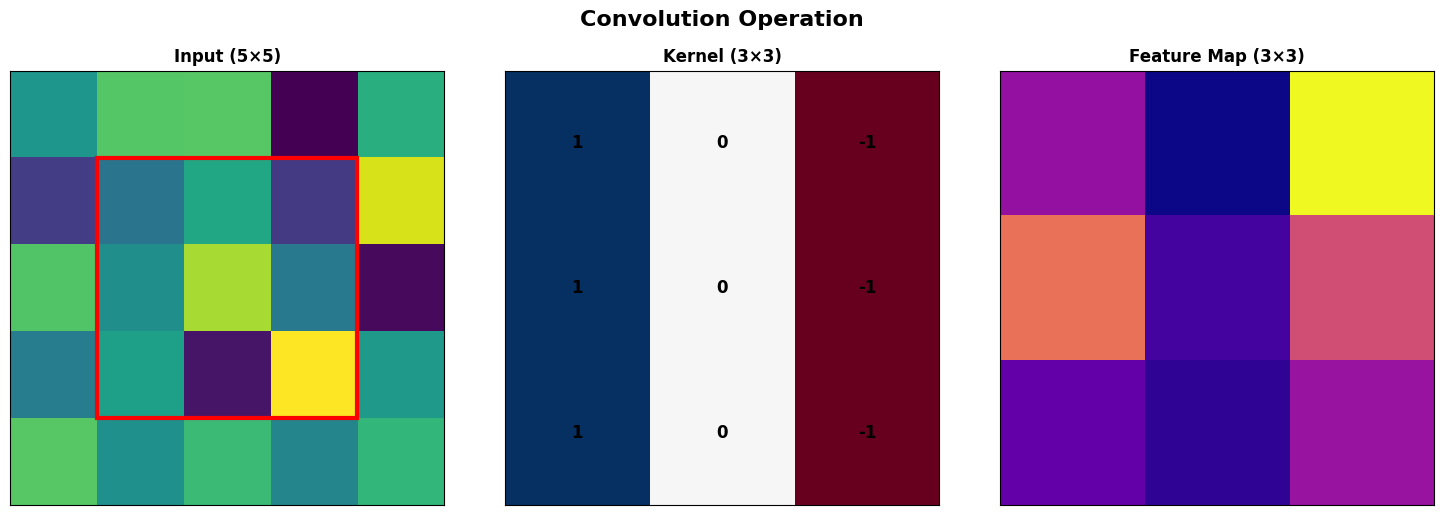

In [1]:
# Visualization of CNN architecture components
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

def visualize_convolution():
    """Demonstrate how convolution operation works"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Input
    input_data = np.random.rand(5, 5)
    axes[0].imshow(input_data, cmap='viridis')
    axes[0].set_title('Input (5×5)', fontweight='bold')
    axes[0].add_patch(Rectangle((0.5, 0.5), 3, 3, fill=False, edgecolor='red', linewidth=3))
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    # Kernel
    kernel = np.array([[1, 0, -1],
                       [1, 0, -1],
                       [1, 0, -1]])
    axes[1].imshow(kernel, cmap='RdBu', vmin=-1, vmax=1)
    axes[1].set_title('Kernel (3×3)', fontweight='bold')
    for i in range(3):
        for j in range(3):
            axes[1].text(j, i, f'{kernel[i, j]}',
                        ha='center', va='center', fontsize=12, fontweight='bold')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    # Output feature map
    output_size = 3  # With valid padding: 5 - 3 + 1 = 3
    output_data = np.random.rand(output_size, output_size)
    axes[2].imshow(output_data, cmap='plasma')
    axes[2].set_title('Feature Map (3×3)', fontweight='bold')
    axes[2].set_xticks([])
    axes[2].set_yticks([])

    plt.suptitle('Convolution Operation', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualize_convolution()

## Summary

This section covered the CNN architecture for magnetic field prediction:

**Key Components**:
- **Convolutional Layers**: Local connectivity with parameter sharing
- **Pooling Layers**: Spatial downsampling for dimension reduction
- **Dilated Convolutions**: Capturing long-range dependencies without additional parameters
- **Encoder-Decoder Structure**: Feature extraction and spatial reconstruction
- **Skip Connections**: Preserving fine-grained spatial information

**Network Specifications**:
- 32 total layers (16 trainable)
- 2.4 million parameters
- Trained on 30,000 samples
- RMS error minimization objective

The next section examines the training process, including the critical role of dilated filters and model selection strategies.